# 02 · Central Tendency and Spread

In the first notebook we looked at the shape of the bills with charts. Now we describe a variable with a few numbers:

1. **Where is the centre?** Mean, median, mode
2. **How spread out is it?** Range, variance, standard deviation
3. **Where does a value stand?** Percentiles and quartiles
4. **Five-number summary and box plot**
5. **Finding outliers with the IQR rule**

Dataset: the same restaurant **tips** data (`data/tips.csv`, 244 bills). See notebook 01 for the column descriptions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mode, multimode

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

tips = pd.read_csv("../data/tips.csv")
tips["tip_percent"] = tips["tip"] / tips["total_bill"] * 100
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


I added one new column, `tip_percent` = tip / bill × 100, because "how generous was the customer" is easier to compare in percent than in dollars.

---
# Part A · Measures of central tendency

> A **measure of central tendency** is one number that tells us where the centre of the data is.

**Why do we need it?** If someone asks "how much do people spend in this restaurant?", you cannot answer with 244 numbers. You answer with one typical value.

## 1. Mean

> **Theory.** The mean is the plain average: add everything, divide by how many values there are.

**Formula**

$$\mu = \frac{\sum_{i=1}^{N} x_i}{N} \qquad\qquad \bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

| Symbol | Meaning |
|---|---|
| $x_i$ | the i-th value |
| $\sum$ | "add them all up" |
| $N$, $\mu$ | population size and population mean |
| $n$, $\bar{x}$ | sample size and sample mean ("x bar") |

The calculation is the same, only the symbols change. We follow the standard notation so other people can read our work.

**Small example:** X = 1, 1, 2, 2, 3, 3, 4, 5, 5, 6

**Manual calculation**

$$\bar{x} = \frac{1+1+2+2+3+3+4+5+5+6}{10} = \frac{32}{10} = 3.2$$

In [2]:
x = [1, 1, 2, 2, 3, 3, 4, 5, 5, 6]

mean_by_hand = sum(x) / len(x)
print("Mean from scratch:", mean_by_hand)
print("Mean with numpy:  ", np.mean(x))

Mean from scratch: 3.2
Mean with numpy:   3.2


> **Check:** Both give 3.2, same as the manual calculation.

### The weak point of the mean: outliers

Now add one strange value, 100, to the same list.

$$\bar{x} = \frac{32 + 100}{11} = \frac{132}{11} = 12$$

In [3]:
x_with_outlier = x + [100]
print("Mean without 100:", np.mean(x))
print("Mean with 100:   ", np.mean(x_with_outlier))

Mean without 100: 3.2
Mean with 100:    12.0


One single value moved the mean from 3.2 to 12, and now the "average" is bigger than 10 of the 11 values. The mean is **sensitive to outliers**.

## 2. Median

> **Theory.** The median is the middle value after sorting.

Steps:
1. Sort the values.
2. If $n$ is odd, take the middle value.
3. If $n$ is even, take the average of the two middle values.

**Formula (position of the median)**

$$\text{position} = \frac{n + 1}{2}$$

**Small example and manual calculation**

- 1, 1, 2, 2, 3, **3**, 4, 5, 5, 6, 100 → n = 11, position (11+1)/2 = 6 → median = **3**
- Add 112 as well (n = 12) → position 6.5 → average of the 6th and 7th values = (3 + 4) / 2 = **3.5**

In [4]:
def median_by_hand(values):
    values = sorted(values)
    n = len(values)
    middle = n // 2
    if n % 2 == 1:
        return values[middle]
    return (values[middle - 1] + values[middle]) / 2

print("Median of 11 values:", median_by_hand(x_with_outlier), "| numpy:", np.median(x_with_outlier))
print("Median of 12 values:", median_by_hand(x_with_outlier + [112]), "| numpy:", np.median(x_with_outlier + [112]))

Median of 11 values: 3 | numpy: 3.0
Median of 12 values: 3.5 | numpy: 3.5


> **Check:** The outlier 100 barely affects the median (still 3). That is why the median is preferred for data with outliers, like salaries or house prices.

## 3. Mode

> **Theory.** The mode is the value that appears most often. It is the only measure of centre that works for **categorical** data (you cannot average "Sat" and "Sun").

**Small example:** 1, 2, 2, 3, 3, 3, 4, 5, 6, 6, 7 → 3 appears three times → **mode = 3**.

A dataset can have more than one mode: 1, 2, 2, 3, 3, 4, 4, 5, 6 has three modes (2, 3 and 4).

In [5]:
print("Mode:", mode([1, 2, 2, 3, 3, 3, 4, 5, 6, 6, 7]))
print("All modes:", multimode([1, 2, 2, 3, 3, 4, 4, 5, 6]))

Mode: 3
All modes: [2, 3, 4]


### Where this is used in practice: filling missing values

A common data-cleaning job is filling empty cells. The choice follows directly from what we just saw:

| Kind of column | Fill missing values with | Why |
|---|---|---|
| Continuous, no big outliers | Mean | Uses all the information |
| Continuous with outliers | Median | Not pulled by extreme values |
| Categorical | Mode | The only one that works on categories |

## 4. Mean, median and mode on the real data

In [6]:
bill = tips["total_bill"]

print("Total bill")
print("  mean  :", round(bill.mean(), 2))
print("  median:", round(bill.median(), 2))
print("  mode  :", bill.mode().tolist(), "(appears", (bill == bill.mode()[0]).sum(), "times)")
print()
print("Most common day (mode of a category):", tips["day"].mode()[0])

Total bill
  mean  : 19.79
  median: 17.8
  mode  : [13.42] (appears 3 times)

Most common day (mode of a category): Sat


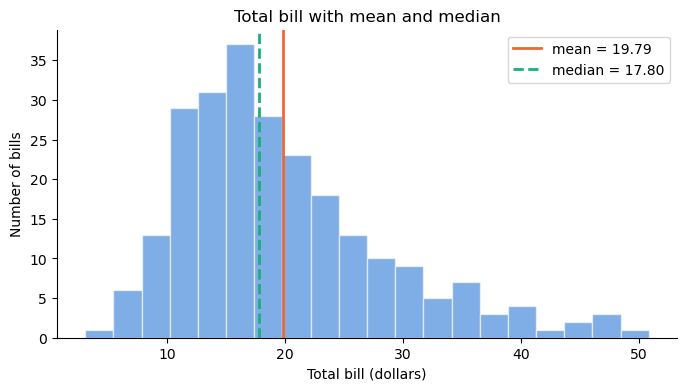

In [7]:
fig, ax = plt.subplots()
ax.hist(bill, bins=20, color=BLUE, alpha=0.6, edgecolor="white")
ax.axvline(bill.mean(), color=ORANGE, linewidth=2, label=f"mean = {bill.mean():.2f}")
ax.axvline(bill.median(), color=GREEN, linewidth=2, linestyle="--", label=f"median = {bill.median():.2f}")
ax.set_title("Total bill with mean and median")
ax.set_xlabel("Total bill (dollars)")
ax.set_ylabel("Number of bills")
ax.legend()
plt.show()

The mean (19.79) is to the right of the median (17.80). The few large bills on the right pull the mean up. The mode of `total_bill` is not very useful here: with continuous money values, almost every amount is unique, so the "most common" value (13.42) appears only 3 times out of 244.

### Skewness: what the gap between mean and median tells us

| Shape | Relation | Example |
|---|---|---|
| Symmetric | mean ≈ median ≈ mode | Heights of adults |
| Right-skewed (long tail to the right) | mean > median | Bills, salaries, house prices |
| Left-skewed (long tail to the left) | mean < median | Age at retirement, easy exam scores |

In [8]:
print("Skewness of total_bill:", round(bill.skew(), 2))

Skewness of total_bill: 1.13


A positive skewness value confirms the long right tail. Around 0 would mean symmetric.

---
# Part B · Measures of spread (dispersion)

> **Dispersion** means spread: how far the values are from each other and from the centre.

**Why do we need it?** Look at these two lists:

- A = 1, 1, 2, 2, 4 → mean = 2
- B = 2, 2, 2, 2, 2 → mean = 2

Same mean, but they are clearly not the same. B never changes, A jumps around. The mean alone hides this, so we need a number for the spread.

## 5. Range

The simplest spread: range = max − min. For A it is 4 − 1 = 3, for B it is 0. It only uses two values, so one outlier can blow it up. That is why we need better measures.

## 6. Variance

> **Theory.** Variance is the **average squared distance from the mean**. We square the distances so that negative and positive ones don't cancel out.

**Formula**

$$\sigma^2 = \frac{\sum_{i=1}^{N} (x_i - \mu)^2}{N} \qquad\qquad s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}$$

| Symbol | Meaning |
|---|---|
| $\sigma^2$ | population variance ("sigma squared") |
| $s^2$ | sample variance |
| $x_i - \bar{x}$ | distance of a value from the mean |
| $n - 1$ | degrees of freedom (Bessel's correction) |

**Why n − 1 for a sample?** The sample mean $\bar{x}$ is calculated from the same values, so the values are always a bit closer to $\bar{x}$ than to the true population mean $\mu$. Dividing by n would give a variance that is too small on average. Dividing by the slightly smaller number n − 1 fixes this. We will check it with a simulation below.

Read more: [Bessel's correction (Wikipedia)](https://en.wikipedia.org/wiki/Bessel%27s_correction)

**Small example:** 1, 2, 2, 3, 4, 5 (n = 6)

**Manual calculation.** First the mean: 17 / 6 = 2.83

| $x_i$ | $\bar{x}$ | $x_i - \bar{x}$ | $(x_i - \bar{x})^2$ |
|---|---|---|---|
| 1 | 2.83 | −1.83 | 3.36 |
| 2 | 2.83 | −0.83 | 0.69 |
| 2 | 2.83 | −0.83 | 0.69 |
| 3 | 2.83 | 0.17 | 0.03 |
| 4 | 2.83 | 1.17 | 1.36 |
| 5 | 2.83 | 2.17 | 4.69 |
| | | **sum** | **10.83** |

- Treat it as a population: $\sigma^2 = 10.83 / 6 = 1.81$
- Treat it as a sample: $s^2 = 10.83 / 5 = 2.17$

In [9]:
values = [1, 2, 2, 3, 4, 5]
n = len(values)
mean_value = sum(values) / n

squared_distances = [(v - mean_value) ** 2 for v in values]
sum_squares = sum(squared_distances)

print("Sum of squared distances:", round(sum_squares, 2))
print("Population variance (/ n)    :", round(sum_squares / n, 2))
print("Sample variance     (/ n - 1):", round(sum_squares / (n - 1), 2))

Sum of squared distances: 10.83
Population variance (/ n)    : 1.81
Sample variance     (/ n - 1): 2.17


In [10]:
# docs: https://numpy.org/doc/stable/reference/generated/numpy.var.html
print("numpy  np.var(values)         :", round(np.var(values), 2), " <- divides by n by default")
print("numpy  np.var(values, ddof=1) :", round(np.var(values, ddof=1), 2))
print("pandas pd.Series(values).var():", round(pd.Series(values).var(), 2), " <- divides by n - 1 by default")

numpy  np.var(values)         : 1.81  <- divides by n by default
numpy  np.var(values, ddof=1) : 2.17
pandas pd.Series(values).var(): 2.17  <- divides by n - 1 by default


> **Watch out:** numpy and pandas use **different defaults**. `np.var` divides by n, `pandas.var` divides by n − 1. The `ddof` argument ("delta degrees of freedom") controls it. This difference causes real bugs when people mix the two libraries.

### Checking Bessel's correction with a simulation

We pretend the 244 bills are the population and we know its true variance. Then we take 10,000 small samples (n = 5) and compute the variance of each one both ways.

In [11]:
np.random.seed(0)
population = tips["total_bill"].to_numpy()
true_variance = np.var(population)

divide_by_n = []
divide_by_n_minus_1 = []
for _ in range(10_000):
    s = np.random.choice(population, size=5)
    divide_by_n.append(np.var(s))
    divide_by_n_minus_1.append(np.var(s, ddof=1))

print("True population variance  :", round(true_variance, 1))
print("Average of  / n           :", round(np.mean(divide_by_n), 1))
print("Average of  / (n - 1)     :", round(np.mean(divide_by_n_minus_1), 1))

True population variance  : 78.9
Average of  / n           : 63.0
Average of  / (n - 1)     : 78.7


> **Check:** Dividing by n is too small on average (it underestimates). Dividing by n − 1 lands right on the true value. That is the whole reason for the n − 1.

## 7. Standard deviation

> **Theory.** Variance is in *squared* units (dollars²), which is hard to imagine. The **standard deviation** is the square root of the variance, so it is back in the original unit (dollars).

$$\sigma = \sqrt{\sigma^2} \qquad\qquad s = \sqrt{s^2}$$

**Manual calculation** for 1, 2, 2, 3, 4, 5: $s = \sqrt{2.17} = 1.47$

Roughly: "a typical value is about 1.47 away from the mean".

In [12]:
print("Standard deviation from scratch:", round((sum_squares / (n - 1)) ** 0.5, 2))
print("Standard deviation with pandas :", round(pd.Series(values).std(), 2))

Standard deviation from scratch: 1.47
Standard deviation with pandas : 1.47


### Spread on the real data: lunch vs dinner bills

In [13]:
summary = tips.groupby("time")["total_bill"].agg(["count", "mean", "median", "var", "std"]).round(2)
summary

,count,mean,median,var,std
time,,,,,
Dinner,176,20.80,18.39,83.58,9.14
Lunch,68,17.17,15.96,59.50,7.71


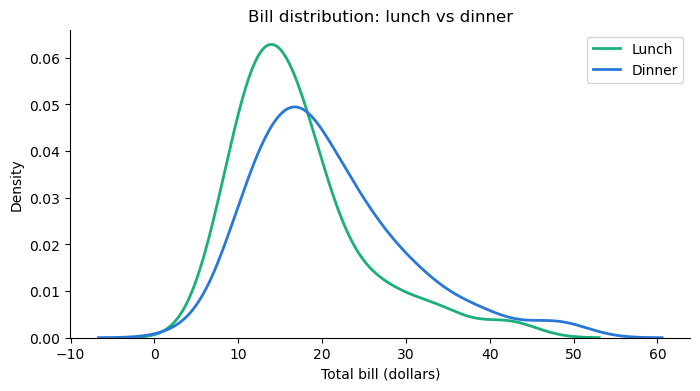

In [14]:
fig, ax = plt.subplots()
for time, colour in [("Lunch", GREEN), ("Dinner", BLUE)]:
    # docs: https://seaborn.pydata.org/generated/seaborn.kdeplot.html
    sns.kdeplot(tips.loc[tips["time"] == time, "total_bill"], color=colour, linewidth=2, label=time, ax=ax)
ax.set_title("Bill distribution: lunch vs dinner")
ax.set_xlabel("Total bill (dollars)")
ax.set_ylabel("Density")
ax.legend()
plt.show()

Dinner bills are higher on average **and** more spread out (std 9.14 vs 7.71 dollars). The dinner curve is wider and flatter. Bigger standard deviation = wider curve.

---
# Part C · Percentiles and quartiles

## 8. Percentiles

> **Theory.**
>
> A **percentile** is a value below which a certain percentage of the data lies.

If your exam score is at the 90th percentile, 90% of students scored below you. Percentiles are used everywhere: growth charts for babies, exam ranks, website loading times ("95% of pages load in under 2 seconds").

**Formulas** (the version used in many textbooks)

$$\text{Percentile rank of } x = \frac{\text{number of values below } x}{n} \times 100$$

$$\text{Position of the P-th percentile} = \frac{P}{100} \times (n + 1)$$

**Small example:** 2, 2, 3, 4, 5, 5, 5, 6, 7, 8, 8, 8, 8, 8, 9, 9, 10, 11, 11, 12 (n = 20, already sorted)

**Manual calculation**

1. Percentile rank of 10: there are 16 values below 10 → 16 / 20 × 100 = **80th percentile**
2. Value at the 25th percentile: position = 0.25 × 21 = 5.25 → between the 5th value (5) and the 6th value (5) → **5**

In [15]:
data = [2, 2, 3, 4, 5, 5, 5, 6, 7, 8, 8, 8, 8, 8, 9, 9, 10, 11, 11, 12]

def percentile_rank(values, x):
    below = sum(1 for v in values if v < x)
    return below / len(values) * 100

print("Percentile rank of 10:", percentile_rank(data, 10))
print("Percentile rank of 11:", percentile_rank(data, 11))

Percentile rank of 10: 80.0
Percentile rank of 11: 85.0


In [16]:
# docs: https://numpy.org/doc/stable/reference/generated/numpy.percentile.html
print("25th percentile, textbook (n + 1) rule:", np.percentile(data, 25, method="weibull"))
print("25th percentile, numpy default rule   :", np.percentile(data, 25))

25th percentile, textbook (n + 1) rule: 5.0
25th percentile, numpy default rule   : 5.0


> **Note:** There are several slightly different rules for percentiles. The textbook (n + 1) rule is called `"weibull"` in numpy. The numpy and pandas default (`"linear"`) can give a slightly different answer on small data. On big datasets the difference disappears. Just be consistent.

Read more: the nine percentile methods are listed in the [numpy.percentile documentation](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)

## 9. Quartiles

Quartiles are three special percentiles that cut the sorted data into four equal parts:

| Name | Percentile | Meaning |
|---|---|---|
| Q1 | 25th | a quarter of the data is below it |
| Q2 | 50th | the **median** |
| Q3 | 75th | three quarters of the data is below it |

In [17]:
# docs: https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html
q1, q2, q3 = tips["total_bill"].quantile([0.25, 0.50, 0.75])
print(f"Q1 = {q1:.2f}   Q2 (median) = {q2:.2f}   Q3 = {q3:.2f}")

Q1 = 13.35   Q2 (median) = 17.80   Q3 = 24.13


So a quarter of the bills are below 13.35 dollars, half are below 17.80, and three quarters are below 24.13.

---
# Part D · Five-number summary, box plot and outliers

## 10. Five-number summary

1. Minimum
2. Q1
3. Median
4. Q3
5. Maximum

Together they describe the centre, the spread and the range in five numbers.

## 11. The IQR rule for outliers

> **Theory.** The **interquartile range (IQR)** is the width of the middle 50% of the data. Values that are far outside this middle part are flagged as outliers.

**Formula**

$$IQR = Q3 - Q1$$
$$\text{Lower fence} = Q1 - 1.5 \times IQR \qquad \text{Upper fence} = Q3 + 1.5 \times IQR$$

Anything below the lower fence or above the upper fence is an outlier.

**Small example:** 1, 2, 2, 2, 3, 3, 4, 5, 5, 5, 6, 6, 6, 6, 7, 8, 8, 9, 27 (n = 19)

**Manual calculation** (with the (n + 1) rule)

1. Q1 position = 0.25 × 20 = 5 → 5th value = **3**
2. Q3 position = 0.75 × 20 = 15 → 15th value = **7**
3. IQR = 7 − 3 = **4**
4. Lower fence = 3 − 1.5 × 4 = **−3**
5. Upper fence = 7 + 1.5 × 4 = **13**
6. 27 > 13 → **27 is an outlier**

Five-number summary of this data: min = 1, Q1 = 3, median = 5, Q3 = 7, max = 27. In a box plot the right whisker stops at **9**, the largest value still inside the fences, and 27 is drawn as a separate dot.

In [18]:
data = [1, 2, 2, 2, 3, 3, 4, 5, 5, 5, 6, 6, 6, 6, 7, 8, 8, 9, 27]

q1, q3 = np.percentile(data, [25, 75], method="weibull")
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = [v for v in data if v < lower_fence or v > upper_fence]

print("Q1 =", q1, " Q3 =", q3, " IQR =", iqr)
print("Fences:", lower_fence, "to", upper_fence)
print("Outliers:", outliers)

Q1 = 3.0  Q3 = 7.0  IQR = 4.0
Fences: -3.0 to 13.0
Outliers: [27]


In [19]:
print("Five-number summary:")
print("  min   :", min(data))
print("  Q1    :", q1)
print("  median:", np.median(data))
print("  Q3    :", q3)
print("  max   :", max(data))

inside_fences = [v for v in data if lower_fence <= v <= upper_fence]
print("Largest value inside the fences (end of the whisker):", max(inside_fences))

Five-number summary:
  min   : 1
  Q1    : 3.0
  median: 5.0
  Q3    : 7.0
  max   : 27
Largest value inside the fences (end of the whisker): 9


> **Check:** Same as the manual calculation.

## 12. Box plot

A box plot draws the five-number summary as a picture:

- the **box** goes from Q1 to Q3 (the middle 50%)
- the **line inside** the box is the median
- the **whiskers** go to the furthest points still inside the fences
- **dots** beyond the whiskers are outliers

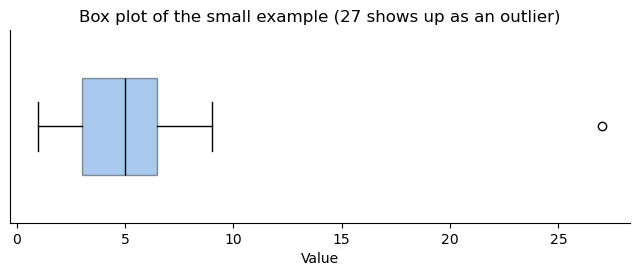

In [20]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.boxplot(data, vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor=BLUE, alpha=0.4), medianprops=dict(color="black"))
ax.set_title("Box plot of the small example (27 shows up as an outlier)")
ax.set_xlabel("Value")
ax.set_yticks([])
plt.show()

The box covers 3 to 7, the median line sits at 5, and the single dot on the right is the outlier 27.

## 13. Outliers in the real bills

In [21]:
bill = tips["total_bill"]

q1, q3 = bill.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print("Five-number summary of total_bill")
print(f"  min = {bill.min():.2f}, Q1 = {q1:.2f}, median = {bill.median():.2f}, Q3 = {q3:.2f}, max = {bill.max():.2f}")
print(f"IQR = {iqr:.2f}, fences = [{lower_fence:.2f}, {upper_fence:.2f}]")

big_bills = tips[(bill < lower_fence) | (bill > upper_fence)]
print("Number of outlier bills:", len(big_bills))
big_bills.sort_values("total_bill")

Five-number summary of total_bill
  min = 3.07, Q1 = 13.35, median = 17.80, Q3 = 24.13, max = 50.81
IQR = 10.78, fences = [-2.82, 40.30]
Number of outlier bills: 9


,total_bill,tip,sex,smoker,day,time,size,tip_percent
184,40.55,3.00,Male,Yes,Sun,Dinner,2,7.398274
142,41.19,5.00,Male,No,Thur,Lunch,5,12.138869
197,43.11,5.00,Female,Yes,Thur,Lunch,4,11.598237
102,44.30,2.50,Female,Yes,Sat,Dinner,3,5.643341
182,45.35,3.50,Male,Yes,Sun,Dinner,3,7.717751
156,48.17,5.00,Male,No,Sun,Dinner,6,10.379905
59,48.27,6.73,Male,No,Sat,Dinner,4,13.942407
212,48.33,9.00,Male,No,Sat,Dinner,4,18.621974
170,50.81,10.00,Male,Yes,Sat,Dinner,3,19.681165


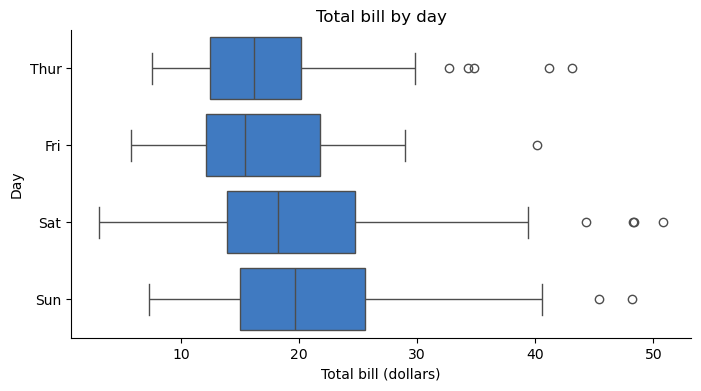

In [22]:
fig, ax = plt.subplots()
# docs: https://seaborn.pydata.org/generated/seaborn.boxplot.html
sns.boxplot(data=tips, x="total_bill", y="day", order=["Thur", "Fri", "Sat", "Sun"], color=BLUE, ax=ax)
ax.set_title("Total bill by day")
ax.set_xlabel("Total bill (dollars)")
ax.set_ylabel("Day")
plt.show()

The box plots let us compare four days in one picture. Saturday and Sunday have higher medians and longer boxes. Notice that each box calculates its **own** fences: Thursday shows five dots because on a quiet weekday a 33 dollar bill is already unusual, while on Saturday the same bill sits comfortably inside the whisker. An outlier is always "unusual compared to its own group".

### Should we delete these outliers?

Not automatically. Look at the outlier rows: 7 of the 9 are dinner bills and most are tables of 3 or more people. These are **real, valid bills**, not typing mistakes. Deleting them would make the restaurant look less profitable than it is.

A good rule of thumb:

| Situation | What to do |
|---|---|
| Clear error (negative bill, age = 250) | Fix or remove |
| Real but extreme value | Keep it, and use robust tools (median, IQR) or report results with and without it |
| Not sure | Ask someone who knows the data (the domain expert) |

---
## Summary

| Measure | Formula / rule | Good for | Weak point |
|---|---|---|---|
| Mean | sum / n | Symmetric data | Pulled by outliers |
| Median | middle value | Skewed data, outliers | Ignores the size of extreme values |
| Mode | most frequent | Categories | Not useful for continuous data |
| Variance | average squared distance | Maths behind many tests | Squared units |
| Standard deviation | √variance | Spread in original units | Pulled by outliers |
| IQR | Q3 − Q1 | Robust spread, outlier fences | Ignores the tails |

Remember: `np.var` / `np.std` divide by n, pandas divides by n − 1.

## What's next

In **03 · Normal Distribution and Z-Score** we meet the famous bell curve, the 68-95-99.7 rule, z-scores, standardisation, and a second way to find outliers.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), chapter 2
- [Bessel's correction, Wikipedia](https://en.wikipedia.org/wiki/Bessel%27s_correction)
- [Box plot, Wikipedia](https://en.wikipedia.org/wiki/Box_plot) · [Interquartile range, Wikipedia](https://en.wikipedia.org/wiki/Interquartile_range)
- [numpy `var`](https://numpy.org/doc/stable/reference/generated/numpy.var.html) (see the `ddof` argument) · [numpy `percentile`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)